# ApexPlanet Data Analytics Internship

## Task 4: Data Storytelling & Statistical Validation

### Objective

The objective of this task is to transform the findings from previous
analyses into a clear business story and statistically validate an
important business finding using hypothesis testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../Task_3/Task3_Dashboard_Data.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Year,Month,Day,Revenue_Per_Item,Age_Group,Year_Month,Customer_Segment
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,February,25,2829.77,26-40,2025-02,Low Value
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,October,14,27906.16,60+,2025-10,Medium Value
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,May,13,37491.06,60+,2025-05,High Value
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,December,2,28541.36,60+,2025-12,Medium Value
4,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,December,2,28541.36,60+,2025-12,High Value


# Business Story

## Business Objective

The objective of the analysis is to understand sales performance,
customer purchasing behavior and the factors that influence revenue.

## Analysis Journey

### Task 1
The raw dataset was cleaned, standardized and transformed into an
analysis-ready dataset.

### Task 2
Exploratory data analysis and SQL were used to identify sales,
product, customer and geographic patterns.

### Task 3
A deeper customer segmentation analysis was performed and an
interactive dashboard was created to monitor important KPIs.

### Task 4
Statistical hypothesis testing is used to determine whether an
observed business difference is statistically significant.

In [4]:
df["Gender"].value_counts()

Gender
Male      564
Female    544
Name: count, dtype: int64

In [5]:
male_sales = df[
    df["Gender"].str.lower() == "male"
]["Total_Sales"].dropna()

female_sales = df[
    df["Gender"].str.lower() == "female"
]["Total_Sales"].dropna()

print("Male observations:", len(male_sales))
print("Female observations:", len(female_sales))

Male observations: 564
Female observations: 544


In [6]:
print(
    "Male Mean Sales:",
    round(male_sales.mean(), 2)
)

print(
    "Female Mean Sales:",
    round(female_sales.mean(), 2)
)

Male Mean Sales: 142493.7
Female Mean Sales: 139040.42


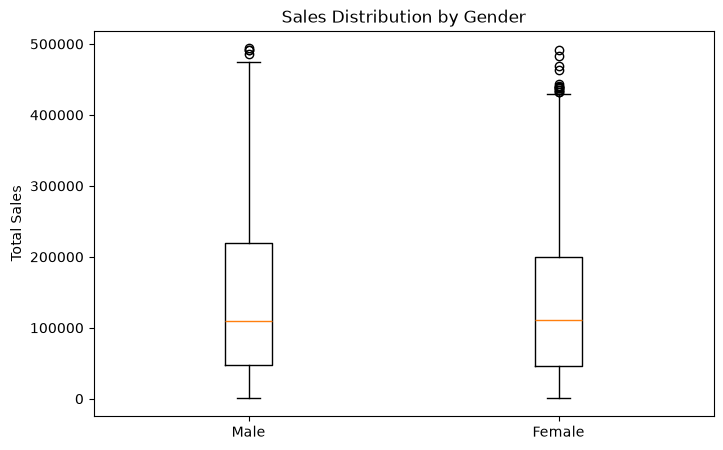

In [8]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [male_sales, female_sales],
    tick_labels=["Male", "Female"]
)

plt.title("Sales Distribution by Gender")
plt.ylabel("Total Sales")

plt.show()

In [9]:
t_statistic, p_value = stats.ttest_ind(
    male_sales,
    female_sales,
    equal_var=False
)

print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

T-Statistic: 0.5001221293596948
P-Value: 0.6170885789261307


In [10]:
alpha = 0.05

if p_value < alpha:

    print("Reject the Null Hypothesis.")

    print(
        "There is a statistically significant "
        "difference in average sales between the groups."
    )

else:

    print("Fail to reject the Null Hypothesis.")

    print(
        "There is insufficient statistical evidence "
        "of a difference in average sales between the groups."
    )

Fail to reject the Null Hypothesis.
There is insufficient statistical evidence of a difference in average sales between the groups.


In [11]:
mean_difference = male_sales.mean() - female_sales.mean()

se = np.sqrt(
    male_sales.var(ddof=1) / len(male_sales)
    +
    female_sales.var(ddof=1) / len(female_sales)
)

ci_low = mean_difference - 1.96 * se
ci_high = mean_difference + 1.96 * se

print(
    "Mean Difference:",
    round(mean_difference, 2)
)

print(
    "Approx. 95% Confidence Interval:",
    round(ci_low, 2),
    "to",
    round(ci_high, 2)
)

Mean Difference: 3453.28
Approx. 95% Confidence Interval: -10080.27 to 16986.82


# Statistical Interpretation

Significance Level: α = 0.05

The hypothesis was evaluated using an independent-samples Welch's
t-test.

The p-value obtained from the analysis was compared against the
5% significance level.

If p < 0.05, the null hypothesis is rejected.

If p >= 0.05, we fail to reject the null hypothesis.

The final business conclusion should therefore be based on the actual
p-value obtained from the analysis rather than visual differences alone.

# Business Recommendations

Based on the complete analysis:

1. Focus retention efforts on high-value customers.
2. Develop strategies to move medium-value customers toward the
   high-value segment.
3. Prioritize high-performing products and categories.
4. Monitor geographic differences in sales performance.
5. Track monthly KPI trends using the interactive dashboard.
6. Use statistically validated findings when designing customer
   targeting strategies.